# 3. Score it, plot it, animate it

**You need: one GPU** (only if the rollout is not already cached; the figures
and animations are CPU work).

**Runtime: about 4 minutes** (measured: 215 s and 219 s), most of it encoding animations.

This notebook runs the shipped evaluation pipeline and then takes it apart, so
you can see where every number in `report.md` comes from. Read
[`docs/06_evaluation.md`](../docs/06_evaluation.md) alongside.

In [1]:
import json
import os
import subprocess
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, Video, display

# Only the noisy third-party deprecations, NOT everything: a bare
# `filterwarnings("ignore")` also silences all 13 of this kit's own
# diagnostics -- including the figure- and animation-skip warnings, which is
# how a run comes back with 4 figures where the last one had 10 and nobody
# notices.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 100

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

RUN = "task6_tiny"          # the shipped 4500-step `tiny` model
OUT = Path("evalstore") / RUN
print("repo:", REPO)


def run_and_show(cmd, head=0, tail=None, show=True):
    """Run `cmd` and show what it said -- **stderr included**.

    `subprocess.run(..., capture_output=True)` keeps the two streams apart, and a
    cell that prints only `.stdout` throws away the half worth reading. Every
    startup refusal in this kit prints to stdout, but tracebacks, Lightning's
    progress bars and every `warnings.warn` go to **stderr**: printing stdout
    alone turns a failure into `exit 1` and nothing else, and the notebook then
    dies two cells later on a `FileNotFoundError` that looks unrelated -- while
    the message naming the fix sits unread.

    `stderr=STDOUT` merges the two in the order they were written, so the tail of
    a failed run is the reason it failed. A non-zero exit raises here, in the
    cell that caused it, rather than in the next cell that needs the output.
    """
    started = time.time()
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    elapsed = time.time() - started
    lines = [ln for ln in proc.stdout.replace("\r", "\n").splitlines() if ln.strip()]
    keep = 40 if proc.returncode else tail
    shown = lines[-keep:] if keep else lines
    if head and not proc.returncode and len(lines) > head + len(shown):
        shown = lines[:head] + [f"   ... {len(lines) - head - len(shown)} lines ..."] + shown
    if show or proc.returncode:
        print("\n".join(shown))
        print(f"\nexit {proc.returncode}, {elapsed:.0f} s wall")
    if proc.returncode:
        raise RuntimeError(
            f"`{' '.join(cmd[:3])} ...` exited {proc.returncode}. The reason is in the output"
            " above: it is on stderr, which a bare `.stdout` would have discarded."
        )
    return proc

repo: /p/scratch/training2635/4_ocean_ai/nowak2/hackathon-ocean-sea-ice


## 1. One command

`make eval NAME=<run> LEAD_DAYS=10` does everything. We call the same entry
point so we can watch it.

In [2]:
proc = run_and_show(
    [".venv/bin/python", "-m", "oceanarches.evaluation.run_eval",
     "--exp", RUN, "--lead-days", "10"],
    tail=30,
)

[   1.2s] statistics: normalisation from 400 dates from 1993-2025, climatology from 33 of 33 years (1993-2025)
Loading task6_tiny on cuda ...
/p/scratch/training2635/4_ocean_ai/nowak2/hackathon-ocean-sea-ice/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Restored from modelstore/task6_tiny/checkpoints/checkpoint_global_step=4500.ckpt
  checkpoint checkpoint_global_step=4500.ckpt, component full
0it [00:00, ?it/s]
3it [00:00, 25.38it/s]
5it [00:00, 25.34it/s]
[   9.9s] Reusing cached rollout in evalstore/task6_tiny/lead10d
  loss[model] = 2.1144
  loss[persistence] = 2.2605
  loss[climatology] = 48.7485
0it [00:00, ?it/s]
5it [00:00, 155.74it/s]
[  10.1s] Reusing cached free rollout in evalstore/task6_tiny/free90d
[  10.1s] Rendering figures
  reusing 12 cached figure

If you have run this before, most of the output says "Reusing cached rollout".
The cache is keyed on a **content hash of the checkpoint**, a hash of its
`config.yaml` and a digest of `oceanarches/stats/`, not on the file name --
geoarches names checkpoints after the global step, so retraining a run with the
same `max_steps` writes different weights under an identical name, and a
name-keyed cache would happily report the previous model's scores. Rebuilding the
statistics invalidates it too, on purpose: the climatology is one of the two
baselines, so it is a different comparison.

**What a re-run costs.** Running this cell again with nothing changed reuses the
cached rollout *and* the cached figures and animations. Measured on `task6_tiny`
at `--lead-days 10`, the identical command each time:

| run | wall clock |
|---|---|
| cold | **231.9 s** (load 7.6, rollout 20.0, free rollout 16.3, figures 27.5, animations 155.8) |
| warm, identical command | **5.1 s** |
| warm, `--skip-animations` | **3.2 s** |

Change something -- a different `--lead-days`, `--n-inits`, a retrained
checkpoint -- and it re-renders. While you iterate, add `--skip-animations` to
the command above (`EVAL_ARGS="--skip-animations"` through `make eval`) to skip
the most expensive stage outright: it is two thirds of a cold run.

In [3]:
for group in ("figures", "animations"):
    print(group)
    for path in sorted((OUT / group).iterdir()):
        print(f"   {path.name:34s} {path.stat().st_size / 1024:8.0f} kB")
print("reports")
for name in ("report.md", "report.html", "summary.json"):
    print(f"   {name:34s} {(OUT / name).stat().st_size / 1024:8.0f} kB")

figures
   .render_cache.json                        0 kB
   01_rmse_vs_lead.png                     149 kB
   02_scorecard.png                        155 kB
   03_seaice_vs_lead.png                   106 kB
   04_map_siconc.png                       386 kB
   04_map_thetao.png                      1019 kB
   04_map_zos.png                         1056 kB
   05_depth_hovmoller.png                  124 kB
   06_seaice_polar.png                     673 kB
   07_free_timeseries.png                  148 kB
   08_power_spectra.png                    232 kB
   comparison_rmse.png                     168 kB
   comparison_rmse_seaice.png               62 kB
animations
   .render_cache.json                        0 kB
   free_90d_seaice_arctic.mp4             3555 kB
   free_90d_sst.mp4                       1347 kB
   seaice_antarctic.mp4                    205 kB
   seaice_arctic.mp4                       309 kB
   sst_rollout.mp4                         320 kB
   surface_current_speed.mp4   

## 2. What is in the cache

`evalstore/<run>/lead10d/` holds the metrics as netCDF plus a manifest that
records **everything that changes the numbers**. Reload it through the shipped
loader rather than parsing files by hand:

In [4]:
from oceanarches.evaluation import plots, report, rollout  # noqa: E402


def cached(directory: Path):
    """Reload a finished rollout from its own manifest.

    `RolloutSpec.from_manifest` reads the field list off the dataclass itself,
    so the next field the spec gains -- `statistics_fingerprint` was the most
    recent -- is picked up here automatically. A hand-written list of manifest
    keys silently missed that field once already: this cell used to rebuild a
    spec that no longer matched its own manifest, so `load_cached` refused a
    cache that was perfectly good.
    """
    manifest = json.loads((directory / "manifest.json").read_text())
    spec = rollout.RolloutSpec.from_manifest(manifest)
    result = rollout.load_cached(spec, directory)
    assert result is not None, f"no usable cache in {directory}"
    return result


result = cached(OUT / "lead10d")
free = cached(OUT / "free90d")

print("split                :", result.spec.domain)
print("initialisations      :", result.spec.n_inits, "->", result.init_times[:3], "...")
print("lead time            :", result.spec.lead_days, "days")
print("checkpoint           :", result.spec.checkpoint)
print("checkpoint fingerprint:", result.spec.checkpoint_fingerprint)
print("forecasters scored   :", result.forecaster_keys)
print("losses               :", {k: round(v, 4) for k, v in result.losses.items()})

split                : test
initialisations      : 16 -> ['2021-01-01T12:00:00', '2021-03-14T12:00:00', '2021-05-26T12:00:00'] ...
lead time            : 10 days
checkpoint           : checkpoint_global_step=4500.ckpt
checkpoint fingerprint: 164050058:66d46d3ff993e1cd
forecasters scored   : ['model', 'persistence', 'climatology']
losses               : {'model': 2.1144, 'persistence': 2.2605, 'climatology': 48.7485}


The fingerprint is what makes "every number in this report was measured on
exactly this model" a true statement rather than a statement about a file name.

## 3. The headline table

This is the table the whole pipeline exists to produce: a number, the two
numbers it has to be read against, and the percentage between them.

In [5]:
for day in (1, 10):
    header, rows = report.headline_table(result, day=day)
    display(Markdown(f"**RMSE at day {day}, ocean cells only**\n\n"
                     + "| " + " | ".join(header) + " |\n"
                     + "|" + "---|" * len(header) + "\n"
                     + "\n".join("| " + " | ".join(r) + " |" for r in rows)))

**RMSE at day 1, ocean cells only**

| Variable | Unit | Model | Persistence | Climatology | Model vs persistence |
|---|---|---|---|---|---|
| Sea water potential temperature @ 0 m | degC | 0.1249 | 0.13093 | 0.83651 | -4.6%  (better) |
| Sea ice concentration | 1 | 0.010642 | 0.012685 | 0.060277 | -16.1%  (better) |
| Sea surface height | m | 0.017937 | 0.021653 | 0.090162 | -17.2%  (better) |
| Sea ice thickness | m | 0.012326 | 0.013592 | 0.11749 | -9.3%  (better) |
| Sea water salinity @ 0 m | 1e-3 | 0.074995 | 0.075464 | 0.41899 | -0.6%  (better) |
| Mixed layer depth | m | 10.278 | 11.009 | 22.883 | -6.6%  (better) |

**RMSE at day 10, ocean cells only**

| Variable | Unit | Model | Persistence | Climatology | Model vs persistence |
|---|---|---|---|---|---|
| Sea water potential temperature @ 0 m | degC | 0.56841 | 0.61548 | 0.83097 | -7.6%  (better) |
| Sea ice concentration | 1 | 0.044014 | 0.051583 | 0.060067 | -14.7%  (better) |
| Sea surface height | m | 0.061441 | 0.059344 | 0.090221 | +3.5%  (WORSE) |
| Sea ice thickness | m | 0.046006 | 0.049183 | 0.11636 | -6.5%  (better) |
| Sea water salinity @ 0 m | 1e-3 | 0.29355 | 0.28908 | 0.41683 | +1.5%  (WORSE) |
| Mixed layer depth | m | 21.979 | 23.600 | 22.798 | -6.9%  (better) |

Read it as: *the model beats persistence on every headline variable at day 1,
and has lost sea surface height and surface salinity by day 10.*

Persistence -- "tomorrow looks like today" -- is a genuinely strong baseline on
something as slow as the ocean. Climatology is the line a **long** forecast
falls back to: once your error reaches it, your forecast carries no information
the calendar did not already have.

## 4. Error against lead time

Drawn by the shipped plotting code, so this is literally figure 01 of the
report.

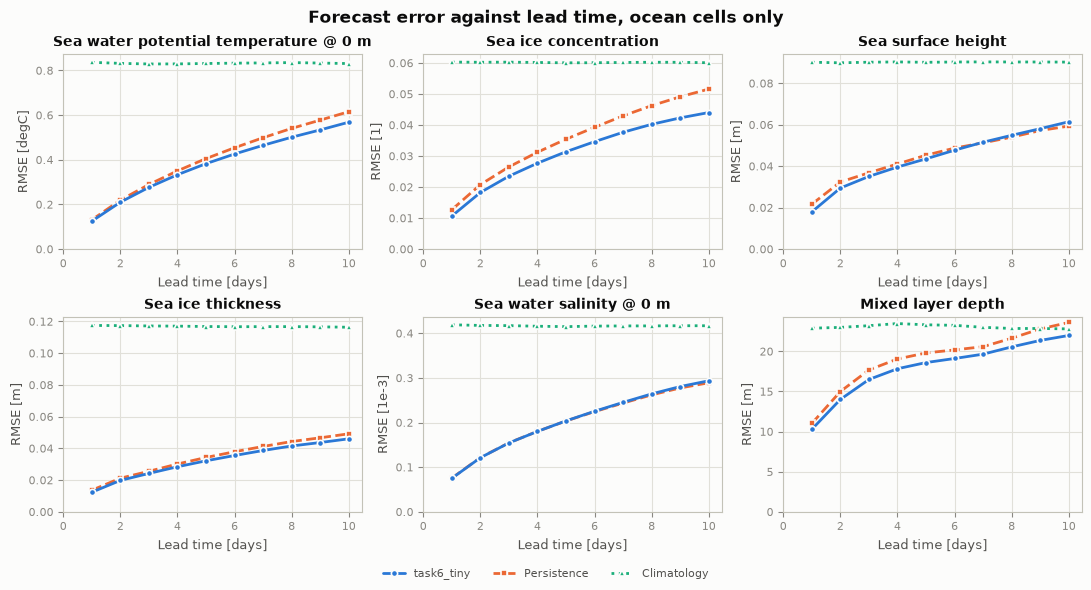

In [6]:
figures = Path("evalstore") / RUN / "figures"
display(Image(filename=str(plots.plot_rmse_vs_lead(result, figures / "01_rmse_vs_lead.png"))))

## 5. The scorecard, and its table

Every variable, every lead time, as a percentage of persistence's error.
**Warm means worse than persistence.** That convention holds in every figure in
this kit: warm is more of the bad thing.

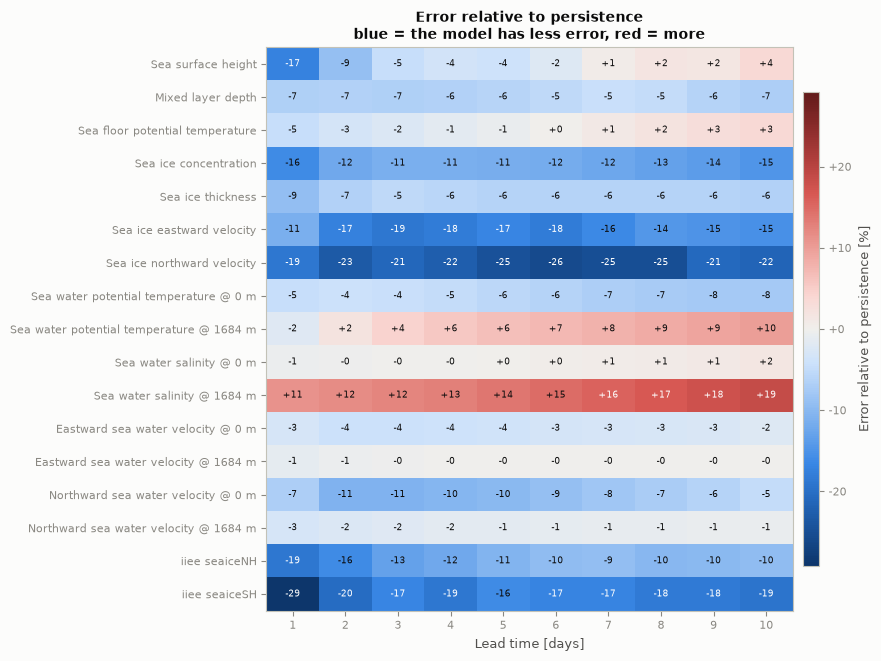

In [7]:
display(Image(filename=str(plots.plot_scorecard(result, figures / "02_scorecard.png"))))

In [8]:
labels, lead_days, matrix = plots.scorecard_table(result)
print(f"{'variable':<28}" + "".join(f"{f'day {d:g}':>9}" for d in lead_days))
for label, row in zip(labels, matrix):
    print(f"{label:<28}" + "".join(f"{100 * v:>+9.1f}" for v in row))
print("\nPercent. Negative = the model's error is that much SMALLER than persistence's.")

variable                        day 1    day 2    day 3    day 4    day 5    day 6    day 7    day 8    day 9   day 10
zos                             -17.2     -9.0     -4.8     -3.6     -3.9     -2.1     +0.6     +1.6     +1.5     +3.5
mlotst                           -6.6     -6.6     -6.7     -6.4     -6.1     -5.3     -4.5     -5.0     -6.3     -6.9
bottomT                          -4.6     -3.3     -2.4     -1.5     -0.7     +0.2     +1.1     +2.0     +2.9     +3.5
siconc                          -16.1    -12.2    -11.3    -11.3    -11.4    -11.8    -12.3    -13.0    -13.9    -14.7
sithick                          -9.3     -6.6     -5.3     -5.8     -6.2     -6.3     -6.2     -6.4     -6.4     -6.5
usi                             -11.3    -17.4    -18.7    -18.2    -16.7    -18.2    -16.2    -14.4    -14.8    -15.3
vsi                             -18.8    -23.2    -21.1    -22.5    -24.5    -25.6    -25.0    -24.9    -20.9    -21.6
thetao0m                         -4.6     -4.2  

Two rows deserve your attention, and they are the most useful things on the
page:

* **deep salinity is worse than persistence** and gets worse with lead time.
  At 1684 m the one-day change is almost zero, so persistence is nearly
  perfect, and any noise the model adds makes it worse. The model already gets
  persistence for free through `add_input_state`, so a variable it makes worse
  is capacity spent badly.
* **the model is too icy**: `extentbias` is positive in both hemispheres and
  grows. And yet its ice-edge error (IIEE) beats persistence -- it is putting
  the edge in a better place while putting too much ice inside it.

## 6. Sea ice, properly

Grid-point RMSE is not how sea ice is judged. What people publish is the
position of the ice **edge** and the area inside it, in millions of square
kilometres.

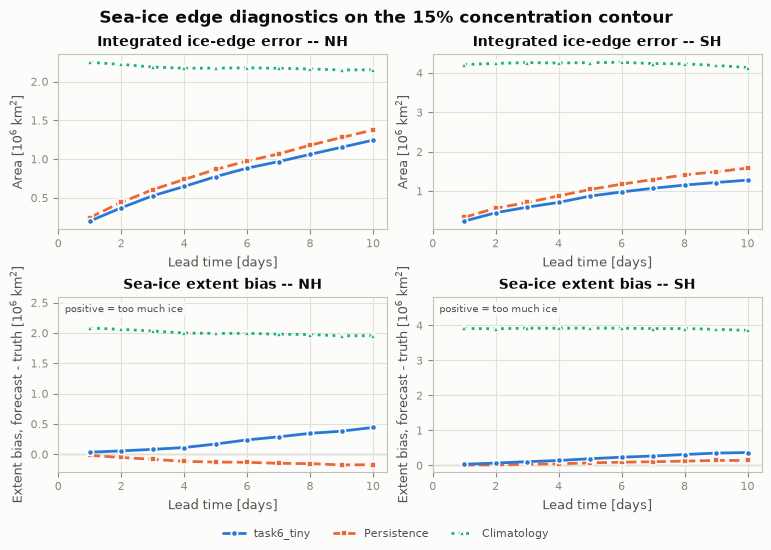

In [9]:
display(Image(filename=str(plots.plot_seaice_vs_lead(result, figures / "03_seaice_vs_lead.png"))))

`iiee` is the Integrated Ice-Edge Error: the total area where model and truth
disagree about whether there is ice. `extentbias` is signed, and **positive
means too much ice**, which is why the axis says so.

## 7. The drift check

The 10-day scores above look respectable. Here is the same model rolled out for
90 days, fed only its own output.

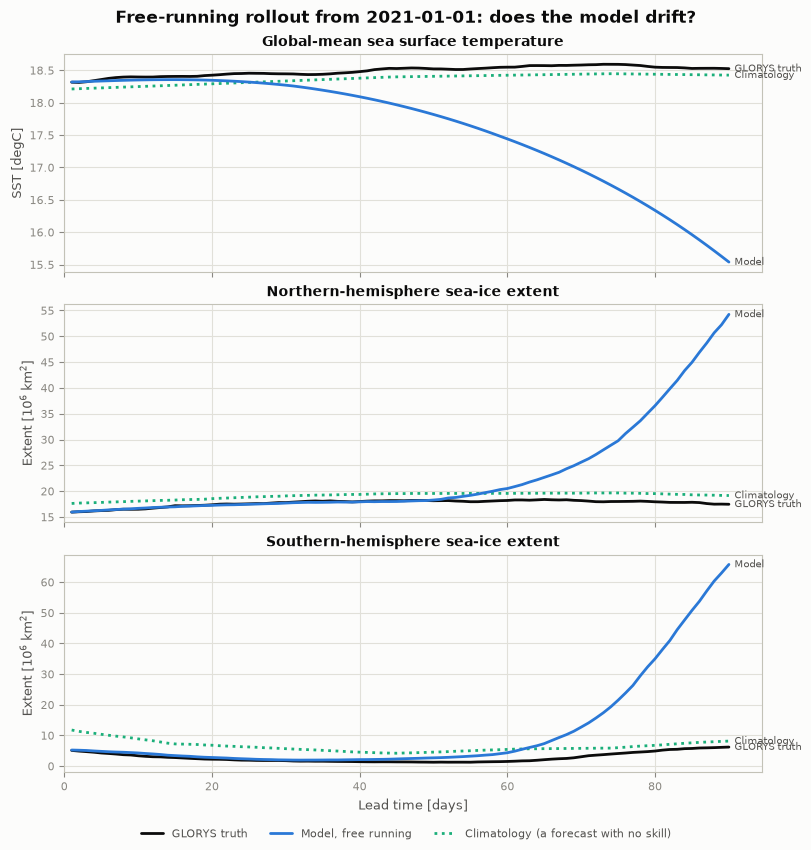

In [10]:
display(Image(filename=str(plots.plot_free_timeseries(free, figures / "07_free_timeseries.png"))))

In [11]:
series = plots.free_running_series(free)
days = series["days"]
print(f"day 1 and day {days[-1]:g} of the free rollout\n")
print(f"{'quantity':<28}{'truth d1':>11}{'model d1':>11}"
      f"{'truth last':>12}{'clim. last':>12}{'model last':>12}")
for name in ("sst", "extent_nh", "extent_sh"):
    curves = series[name]
    truth, model = curves["truth"], curves["model"]
    clim = curves.get("climatology")
    last_clim = f"{clim[-1]:12.3f}" if clim is not None else f"{'-':>12}"
    print(f"{name:<28}{truth[0]:11.3f}{model[0]:11.3f}"
          f"{truth[-1]:12.3f}{last_clim}{model[-1]:12.3f}")

day 1 and day 90 of the free rollout

quantity                       truth d1   model d1  truth last  clim. last  model last
sst                              18.317     18.320      18.526      18.426      15.539
extent_nh                        15.940     15.957      17.464      19.159      54.240
extent_sh                         5.113      5.241       6.206       8.152      65.783


The climatology curve is the control: it sits next to the truth, so the
divergence is the **model**, not the diagnostic.

The model does not settle onto anything. Global mean SST falls by a couple of
degrees; Southern Hemisphere ice extent grows past the size of the Southern
Ocean. A forecast that has merely run out of information relaxes toward the
climatology; this one leaves the attractor. See
[`docs/06`](../docs/06_evaluation.md#65-the-90-day-free-run-and-what-it-tells-you)
for what to do about it.

## 8. Animations

`make eval` writes six. They are two thirds of its runtime, which is what
`--skip-animations` is for while you iterate.

In [12]:
for path in sorted((OUT / "animations").glob("*.mp4")):
    print(f"{path}   {path.stat().st_size / 1024:.0f} kB")

display(Video(str(OUT / "animations" / "seaice_arctic.mp4"), embed=False, width=640))

evalstore/task6_tiny/animations/free_90d_seaice_arctic.mp4   3555 kB
evalstore/task6_tiny/animations/free_90d_sst.mp4   1347 kB
evalstore/task6_tiny/animations/seaice_antarctic.mp4   205 kB
evalstore/task6_tiny/animations/seaice_arctic.mp4   309 kB
evalstore/task6_tiny/animations/sst_rollout.mp4   320 kB
evalstore/task6_tiny/animations/surface_current_speed.mp4   591 kB


(If the player above is blank, open the file directly -- notebook video
playback depends on how your Jupyter server serves static files. Every
animation is also embedded in `report.html`, which is self-contained: 16 media
elements, all of them `data:` URIs, no external references at all. Copy that
one file anywhere and it still works.)

## 9. The report

Everything above, written out. `report.md` for reading in a terminal or on
GitHub, `report.html` to send to somebody.

In [13]:
text = (OUT / "report.md").read_text()
print(text[:2600])
print(f"\n... ({len(text)} characters in total)")

# Evaluation report: task6_tiny

Generated 2026-08-09 13:28 from checkpoint checkpoint_global_step=4500.ckpt on split 'test', 16 initialisations x 10 days.

## Is this model any good?

A forecast error means nothing on its own, so every number below sits next to the two baselines it has to beat. Persistence -- 'tomorrow looks like today' -- is the line a one-day forecast must clear; climatology -- the 1993-2025 monthly mean interpolated to the valid day -- is the line a long forecast eventually falls back to. All three go through exactly the same metric code, on exactly the same samples.

**RMSE at day 1, ocean cells only.**

| Variable | Unit | Model | Persistence | Climatology | Model vs persistence |
|---|---|---|---|---|---|
| Sea water potential temperature @ 0 m | degC | 0.1249 | 0.13093 | 0.83651 | -4.6%  (better) |
| Sea ice concentration | 1 | 0.010642 | 0.012685 | 0.060277 | -16.1%  (better) |
| Sea surface height | m | 0.017937 | 0.021653 | 0.090162 | -17.2%  (better) |
| Se

## 10. What this evaluation does not tell you

Say these out loud before you report a number.

* **16 initialisations is not a climatology.** They are spread over three
  years, which is respectable, but it is 16 samples.
* **The 90-day numbers come from one initialisation**, and so does the forecast
  horizon table.
* **Sea-ice extent on this grid runs high** against published satellite figures
  -- the Arctic March maximum computes to about 18.1 x 10^6 km^2 against a
  published 14-16, because the 1-degree regrid smears the ice edge. Compare
  your model to the truth *on this grid*.
* **GLORYS is a reanalysis, not observations.** It is itself a model with its
  own errors. Beating it is not the same as being right about the ocean.
* **Keep the `holdout` split (2024-2025) untouched** until the end, so that
  there is one set of years nobody has tuned against.

## Next

* [`notebooks/04_couple_two_models.ipynb`](04_couple_two_models.ipynb) -- run
  two specialists together.
* [`docs/07_challenge_ideas.md`](../docs/07_challenge_ideas.md) -- nine
  experiments you can finish in a day.